# SIG19 cluster signatures on the AMP 2023 CD4 subsets: ULM with non-overlapping sets

The reverse of `02`: gene sets come from SIG19 and are scored on AMP. The question is whether the
SIG19 **cluster 3** signature is highest in AMP **T-7 (CD4+ IFNG+ Tph/Tfh)**.

- **Signatures:** SIG19 `leiden_0.5` one-vs-rest pyDESeq2 contrasts
  (`SIG19/analysis/02_DTR_analysis/01_cluster_annotation.ipynb`), mapped mouse -> human.
- **Non-overlapping sets.** Each cluster's set is its top `TOP_N` (100) significant genes; then
  every gene in more than one of the seven sets is removed from all of them, leaving seven disjoint
  sets of 34-63 genes. One-vs-rest contrasts share their "rest" arm, so without this the seven
  scores would partly be the same measurement.
- **Scope:** `T + F` CTAP RA biopsies plus all OA controls, as in `02`; all 13 AMP CD4 subsets.
- **Target:** donor x subset pseudobulk, centred on each donor's mean across subsets.
- **Scoring:** ULM.

The drop falls mostly on the down-genes: the naive/central-memory program (`CCR7`, `LEF1`,
`BACH2`, `TRAT1`, `PIK3IP1`) is shared across clusters. `c3` keeps 41 up / 2 down genes and `c1`
34 up / 5 down, so the ULM `t` mostly measures the cluster's private up-program rather than a
two-sided contrast. Because of the donor centring, a positive score means "above this donor's
average CD4 cell", not "above an unstimulated control".

## 1. Imports and parameters

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import decoupler as dc
from sklearn.preprocessing import StandardScaler
from scipy import stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import cnsplots as cns
cns.settings.panel_label_fontname = "sans serif"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["text.usetex"] = False
sc.settings.verbosity = 1

# Repo-relative paths (inputs: imports_stable/, outputs: analysis_outs/)
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/03_activity_inference_model"

# ---- inputs
AMP_H5AD = f"{IMPORTS_DIR}/external/AMP_2023/amp_2023_cd4_processed.h5ad"
AMP_CTAP = f"{IMPORTS_DIR}/external/AMP_2023/2023_AMP2_CTAP.csv"
SIG19_DEG = f"{IMPORTS_DIR}/SIG19/analysis_outs/cluster_annotation"
SIG19_DEG_TEMPLATE = "leiden0.5_cluster{c}_vs_rest_pydeseq2.csv"
SIG19_CLUSTERS = ["0", "1", "2", "3", "4", "5", "6"]
FOCAL_SIG19 = "c3"          # the signature the notebook is built around
FOCAL_AMP = "T-7"           # the AMP subset it is expected to land in
OUT_DIR = f"{OUTS_DIR}/inference_model_validation_AMP"
# BioMart ortholog map snapshot; if absent, a fresh query is written to OUT_DIR instead
ORTHOLOG_CACHE = f"{IMPORTS_DIR}/SIG13/analysis_outs/inference_model_validation_AMP/mouse_human_orthologs_biomart.csv"
TAG = "ulm_top100_unique"   # prefix for everything this notebook writes

# ---- AMP target parameters
EXPR_LAYER = "log1p_norm"
MIN_CELLS_PER_GENE = 10
MIN_CELLS_PER_PSEUDOBULK = 10
TF_CTAP = "T + F"
CASE, CONTROL = "RA", "control"

# ---- signature parameters
PADJ_MAX = 0.01           # significance filter on the pyDESeq2 results
TOP_N = 100               # cap per set, both directions pooled, applied before the drop
DROP_SHARED_GENES = True  # drop every gene that lands in more than one one-vs-rest set

# ---- gene cleanup, as in 01 and 02
USE_BAD_GENE_FILTER = True
BAD_GENE_PATTERN = (r"^MT-|^MTMR|^MTND|NEAT1|TMSB4X|TMSB10|^RPS|^RPL|^MRP|^FAU$|UBA52|"
                    r"MALAT|TRA[VJ]|TRB[VDJ]|HBA[12]|^IG[HKL]|RP[1-9]+\-|^MTRNR")

os.makedirs(OUT_DIR, exist_ok=True)
print(OUT_DIR)

/data1/rudenska/EYW/git_projects/SIG13/analysis_outs/inference_model_validation_AMP


## 2. Load AMP and apply the scope

Same scope as `02`: OA biopsies get `CTAP = "control"` and `Repeat` biopsies drop out. All 13
subsets are kept; which of them carries the SIG19 signatures is the question.

In [2]:
rna = sc.read_h5ad(AMP_H5AD)

ctap = pd.read_csv(AMP_CTAP)
obs = rna.obs.copy()
idx = obs.index
obs = obs.reset_index(drop=True).merge(ctap, on=["subject_id", "biopsy_id"], how="left")
obs.index = idx

obs["CTAP"] = obs["CTAP"].where(obs["treatment"] != "osteoarthritis control", "control")
obs["group"] = np.where(obs["treatment"] == "osteoarthritis control", CONTROL, CASE)
obs["cluster"] = obs["cluster_name"].astype(str).str.split(":").str[0].str.strip()
rna.obs = obs

in_scope = rna.obs["CTAP"].isin([TF_CTAP, "control"])
print(f"cells outside the '{TF_CTAP}' + {CONTROL} scope: {int((~in_scope).sum())}")

adata = rna[in_scope].copy()
AMP_ORDER = sorted(adata.obs["cluster"].unique(), key=lambda s: int(s.split("-")[1]))
adata.obs["cluster"] = pd.Categorical(adata.obs["cluster"], categories=AMP_ORDER)
adata.obs["group"] = pd.Categorical(adata.obs["group"], categories=[CONTROL, CASE])
print(f"scoped object: {adata.n_obs} cells x {adata.n_vars} genes | "
      f"{adata.obs['subject_id'].nunique()} donors "
      f"({adata.obs.loc[adata.obs['group'] == CASE, 'subject_id'].nunique()} {CASE}, "
      f"{adata.obs.loc[adata.obs['group'] == CONTROL, 'subject_id'].nunique()} {CONTROL}) | "
      f"{len(AMP_ORDER)} subsets")

comp = (adata.obs.groupby("cluster", observed=True)
        .agg(cells=("cluster", "size"), donors=("subject_id", "nunique"))
        .loc[AMP_ORDER])
comp["cluster_name"] = (adata.obs.drop_duplicates("cluster")
                        .set_index("cluster")["cluster_name"].reindex(AMP_ORDER))
display(comp)

cells outside the 'T + F' + control scope: 37616
scoped object: 17816 cells x 20657 genes | 15 donors (8 RA, 7 control) | 13 subsets


,cells,donors,cluster_name
cluster,,,
T-0,3046,15,T-0: CD4+ IL7R+ memory
T-1,2577,15,T-1: CD4+ CD161+ memory
T-2,1885,15,T-2: CD4+ IL7R+CCR5+ memory
T-3,1551,13,T-3: CD4+ IFNG- Tph/Tfh
T-4,2144,13,T-4: CD4+ naive
T-5,1415,14,T-5: CD4+ GZMK+ memory
T-6,915,14,T-6: CD4+ memory
T-7,521,14,T-7: CD4+ IFNG+ Tph/Tfh
T-8,753,14,T-8: CD4+ CD25-high Treg


## 3. Gene cleanup

Detection and bad-gene filters are applied once, on the scoped cells, so the pseudobulk and the ULM
share one gene space.

In [3]:
adata.X = adata.layers[EXPR_LAYER].copy()

sc.pp.filter_genes(adata, min_cells=MIN_CELLS_PER_GENE)
print(f"genes in >= {MIN_CELLS_PER_GENE} cells: {adata.n_vars}")

if USE_BAD_GENE_FILTER:
    bad = adata.var_names.str.contains(BAD_GENE_PATTERN, regex=True)
    print(f"bad-gene pattern removes {int(bad.sum())} / {adata.n_vars} genes")
    adata = adata[:, ~bad].copy()
amp_genes = set(adata.var_names)
print(f"scoreable gene space: {adata.n_vars} genes")

genes in >= 10 cells: 17725
bad-gene pattern removes 351 / 17725 genes
scoreable gene space: 17374 genes


## 4. SIG19 signatures

### 4.1 Mouse to human orthologs

Ensembl BioMart `hsapiens_homolog_associated_gene_name`, cached to `OUT_DIR`. A mouse gene with
several human homologs contributes all of them; a human gene reached by several mouse genes keeps
the most significant row. Genes are mapped and restricted to the AMP gene space before the `TOP_N`
cap.

In [4]:
if os.path.exists(ORTHOLOG_CACHE):
    ortho = pd.read_csv(ORTHOLOG_CACHE)
    print(f"ortholog map loaded from cache: {ORTHOLOG_CACHE}")
else:
    from pybiomart import Dataset
    ds = Dataset(name="mmusculus_gene_ensembl", host="http://www.ensembl.org")
    ortho = ds.query(attributes=["external_gene_name",
                                 "hsapiens_homolog_associated_gene_name"])
    ortho.columns = ["mouse_gene", "human_gene"]
    ortho = ortho[ortho["human_gene"].notna() & (ortho["human_gene"] != "")].drop_duplicates()
    ortho.to_csv(f"{OUT_DIR}/mouse_human_orthologs_biomart.csv", index=False)

print(f"{len(ortho)} mouse-human pairs | {ortho['mouse_gene'].nunique()} mouse genes "
      f"| {ortho['human_gene'].nunique()} human genes")


def load_contrast(filename):
    """One pyDESeq2 table -> one row per human gene AMP can score."""
    d = pd.read_csv(f"{SIG19_DEG}/{filename}")
    d = d.rename(columns={"variable": "mouse_gene", "log_fc": "logFC",
                          "p_value": "pvalue", "adj_p_value": "padj"})
    d = d.dropna(subset=["pvalue", "padj", "logFC"])
    d = d.merge(ortho, on="mouse_gene", how="inner")
    d = d[d["human_gene"].isin(amp_genes)]
    return d.sort_values("pvalue").drop_duplicates("human_gene")


deg, attrition = {}, []
for c in SIG19_CLUSTERS:
    d = load_contrast(SIG19_DEG_TEMPLATE.format(c=c))
    deg[f"c{c}"] = d
    attrition.append(dict(cluster=f"c{c}", in_amp_space=len(d),
                          sig=int((d["padj"] < PADJ_MAX).sum()),
                          sig_up=int(((d["padj"] < PADJ_MAX) & (d["logFC"] > 0)).sum())))

SIG19_ORDER = [f"c{c}" for c in SIG19_CLUSTERS]
attrition = pd.DataFrame(attrition).set_index("cluster").loc[SIG19_ORDER]
attrition["sig_down"] = attrition["sig"] - attrition["sig_up"]
display(attrition)

ortholog map loaded from cache: /data1/rudenska/EYW/git_projects/SIG13/analysis_outs/inference_model_validation_AMP/mouse_human_orthologs_biomart.csv
24844 mouse-human pairs | 20089 mouse genes | 19015 human genes


,in_amp_space,sig,sig_up,sig_down
cluster,,,,
c0,8379,3522,1564,1958
c1,8338,1680,993,687
c2,8423,1403,612,791
c3,8400,1835,1032,803
c4,8425,1690,866,824
c5,8197,387,186,201
c6,8193,504,296,208


### 4.2 Top-`TOP_N` sets, then drop shared genes

`padj < PADJ_MAX`, top `TOP_N` by p-value (both directions pooled), `weight = sign(logFC)`; then any
gene in more than one set is removed from all of them. The drop ignores sign: a gene up in `c3` and
down in `c1` would otherwise make those two scores anti-correlated by construction. ±1 weights
avoid assuming mouse fold changes transfer to human tissue.

In [5]:
# candidate sets: the top TOP_N significant genes per cluster, both directions pooled
cand = {}
for ct in SIG19_ORDER:
    sel = deg[ct][deg[ct]["padj"] < PADJ_MAX].nsmallest(TOP_N, "pvalue").copy()
    sel["source"] = ct
    sel["target"] = sel["human_gene"]
    sel["weight"] = np.sign(sel["logFC"])
    cand[ct] = sel[sel["weight"] != 0]

n_sets = pd.Series(np.concatenate([c["target"].to_numpy() for c in cand.values()])).value_counts()
print(f"candidate sets: top {TOP_N} per cluster, {len(n_sets)} distinct genes")
display(n_sets.value_counts().sort_index()
        .rename_axis("in n of 7 candidate sets").rename("n_genes").to_frame().T)

if DROP_SHARED_GENES:
    shared_genes = set(n_sets[n_sets > 1].index)
    sets = {ct: c[~c["target"].isin(shared_genes)].copy() for ct, c in cand.items()}
    print(f"dropped {len(shared_genes)} genes appearing in >1 set")
else:
    shared_genes = set()
    sets = {ct: c.copy() for ct, c in cand.items()}
    print("DROP_SHARED_GENES is False")

members = {ct: set(s["target"]) for ct, s in sets.items()}

summary = []
for ct in SIG19_ORDER:
    s = sets[ct]
    summary.append(dict(cluster=ct, n_candidate=len(cand[ct]), n_genes=len(s),
                        n_up=int((s["weight"] > 0).sum()),
                        n_down=int((s["weight"] < 0).sum()),
                        median_abs_logFC=s["logFC"].abs().median()))
summary = pd.DataFrame(summary).set_index("cluster").loc[SIG19_ORDER]

net = pd.concat(sets.values(), ignore_index=True)[
    ["source", "target", "weight", "mouse_gene", "logFC", "stat", "pvalue", "padj"]]
net.to_csv(f"{OUT_DIR}/sig19_{TAG}_gene_sets.csv", index=False)
summary.to_csv(f"{OUT_DIR}/sig19_{TAG}_gene_set_summary.csv")
display(summary.round(3))

worst = max(len(members[a] & members[b])
            for i, a in enumerate(SIG19_ORDER) for b in SIG19_ORDER[i + 1:])
print(f"largest pairwise overlap after the drop: {worst} genes")
if DROP_SHARED_GENES:
    assert worst == 0, "de-overlapping failed"

print(f"\ntop 25 up-genes of {FOCAL_SIG19}:\n  " + ", ".join(
    sets[FOCAL_SIG19].query("weight > 0").nsmallest(25, "pvalue")["target"]))
print(f"\nall {int((sets[FOCAL_SIG19]['weight'] < 0).sum())} down-genes of {FOCAL_SIG19}:\n  "
      + ", ".join(sets[FOCAL_SIG19].query("weight < 0").nsmallest(25, "pvalue")["target"]))

candidate sets: top 100 per cluster, 467 distinct genes


in n of 7 candidate sets,1,2,3,4,5,6
n_genes,335,73,29,21,6,3


dropped 132 genes appearing in >1 set


,n_candidate,n_genes,n_up,n_down,median_abs_logFC
cluster,,,,,
c0,100,47,12,35,1.398
c1,100,39,34,5,1.946
c2,100,34,26,8,1.008
c3,100,43,41,2,1.986
c4,100,55,44,11,1.871
c5,100,54,42,12,0.810
c6,100,63,55,8,1.663


largest pairwise overlap after the drop: 0 genes

top 25 up-genes of c3:
  IL18RAP, RUNX2, TBX21, PLEK, EMP1, HIP1, CHSY1, PODNL1, IFI16, SLAMF7, CTSW, ANXA1, FGL2, ATP8B4, ROM1, GZMK, FASLG, KLRD1, COBLL1, ARSB, DOK2, IL10RA, RUNX3, FKBP5, ARAP2

all 2 down-genes of c3:
  ZNRF1, DUSP10


## 5. Pseudobulk AMP

The replicate is the donor x subset profile (at least `MIN_CELLS_PER_PSEUDOBULK` cells), not the
cell. Genes are z-scored across profiles, then each donor's mean across its subsets is subtracted.
This removes donor-level shifts, so scores are between-subset contrasts and one donor's scores sum
to roughly zero.

In [6]:
n_cells = (adata.obs.groupby(["subject_id", "cluster"], observed=True)
           .size().rename("n_cells").reset_index())
keep_pairs = n_cells[n_cells["n_cells"] >= MIN_CELLS_PER_PSEUDOBULK]
print(f"{len(n_cells)} donor x subset pairs | "
      f"{len(keep_pairs)} with >= {MIN_CELLS_PER_PSEUDOBULK} cells")

pb = sc.get.aggregate(adata, by=["subject_id", "cluster"], func="mean", layer=EXPR_LAYER)
pb.X = pb.layers["mean"].copy()
pb.obs["pair"] = (pb.obs["subject_id"].astype(str) + "|" + pb.obs["cluster"].astype(str))
keep_key = set(keep_pairs["subject_id"].astype(str) + "|" + keep_pairs["cluster"].astype(str))
pb = pb[pb.obs["pair"].isin(keep_key)].copy()

pb_meta = pb.obs[["subject_id", "cluster"]].copy()
pb_meta.index = pb.obs["pair"].to_numpy()
pb_meta = pb_meta.merge(n_cells, on=["subject_id", "cluster"], how="left").set_index(pb_meta.index)
donor_meta = adata.obs.drop_duplicates("subject_id").set_index("subject_id")[["CTAP", "group"]]
pb_meta = pb_meta.join(donor_meta, on="subject_id")

X = pb.X.toarray() if hasattr(pb.X, "toarray") else np.asarray(pb.X)
pb_expr = pd.DataFrame(X, index=pb_meta.index, columns=pb.var_names)

# invariant genes come out all-NaN from the scaler and carry no signal
pb_z = pd.DataFrame(StandardScaler().fit_transform(pb_expr),
                    index=pb_expr.index, columns=pb_expr.columns).dropna(axis=1, how="any")
donor_ref = pb_z.groupby(pb_meta["subject_id"].to_numpy()).mean()
pb_delta = pb_z - donor_ref.loc[pb_meta["subject_id"]].to_numpy()

print(f"pseudobulk matrix: {pb_delta.shape[0]} samples x {pb_delta.shape[1]} genes")
cov = {ct: np.mean([g in pb_delta.columns for g in members[ct]]) for ct in SIG19_ORDER}
print("set coverage: " + ", ".join(f"{k} {v:.2f}" for k, v in cov.items()))
display(pb_meta.groupby("cluster", observed=True)
        .agg(n_donors=("subject_id", "nunique"), median_cells=("n_cells", "median"))
        .loc[AMP_ORDER])

183 donor x subset pairs | 150 with >= 10 cells
pseudobulk matrix: 150 samples x 17374 genes
set coverage: c0 1.00, c1 1.00, c2 1.00, c3 1.00, c4 1.00, c5 1.00, c6 1.00


,n_donors,median_cells
cluster,,
T-0,12,219.0
T-1,13,233.0
T-2,13,109.0
T-3,12,95.5
T-4,12,151.0
T-5,12,65.5
T-6,12,65.0
T-7,10,44.5
T-8,11,72.0


## 6. ULM

`estimate` and `pvalue` are the t and p of the ULM slope.

### 6.1 Subset-mean heatmap

One ULM per subset mean; the donor-level test is §6.2.

BH across 91 tests (13 subsets x 7 sets)


2026-09-23 09:58:07 | [INFO] maxp pruned
2026-09-23 09:58:07 | [INFO] cmap pruned
2026-09-23 09:58:07 | [INFO] kern dropped
2026-09-23 09:58:07 | [INFO] post pruned
2026-09-23 09:58:07 | [INFO] FFTM dropped
2026-09-23 09:58:07 | [INFO] GPOS pruned
2026-09-23 09:58:07 | [INFO] GSUB pruned
2026-09-23 09:58:07 | [INFO] glyf pruned
2026-09-23 09:58:07 | [INFO] Added gid0 to subset
2026-09-23 09:58:07 | [INFO] Added first four glyphs to subset
2026-09-23 09:58:07 | [INFO] Closing glyph list over 'MATH': 50 glyphs before
2026-09-23 09:58:07 | [INFO] Glyph names: ['.notdef', '.null', 'A', 'C', 'D', 'G', 'I', 'L', 'M', 'N', 'P', 'S', 'T', 'U', 'a', 'asterisk', 'b', 'c', 'd', 'e', 'eight', 'five', 'four', 'g', 'greater', 'hyphen', 'i', 'j', 'l', 'less', 'm', 'minus', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'zero']
2026-09-23 09:58:07 | [INFO] Glyph IDs:   [0, 1, 2, 3, 13, 16, 17, 19, 20, 21, 22, 23, 24, 25, 26

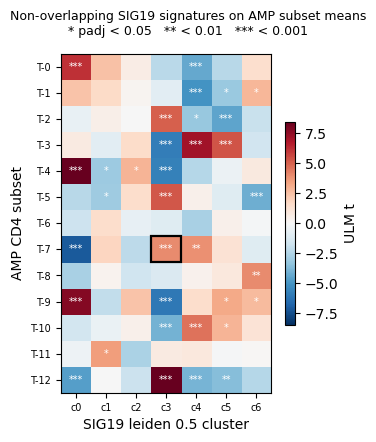

sig19_cluster,c0,c1,c2,c3,c4,c5,c6
amp_cluster,,,,,,,
T-0,6.22,2.47,0.62,-2.29,-4.33,-2.34,1.45
T-1,2.40,1.64,0.21,-0.87,-5.10,-3.15,2.85
T-2,-0.60,0.52,-0.01,5.08,-3.20,-4.49,-1.87
T-3,0.79,-0.91,1.57,-5.88,7.09,5.30,-1.63
T-4,8.48,-3.06,2.87,-5.76,-2.42,-0.47,0.85
T-5,-2.36,-3.03,1.52,5.25,0.40,-1.02,-4.16
T-6,-1.77,1.50,-0.71,-1.00,-2.76,0.44,-0.18
T-7,-7.12,1.81,-2.22,4.04,3.86,1.20,-1.00
T-8,-2.74,0.32,-1.66,-1.23,0.39,0.87,4.01


In [7]:
STAR_LEVELS = [(0.001, "***"), (0.01, "**"), (0.05, "*")]
STAR_LEGEND = "* padj < 0.05   ** < 0.01   *** < 0.001"


def stars(p):
    """Significance marker for one padj."""
    if p is None or not np.isfinite(p):
        return ""
    return next((mark for cut, mark in STAR_LEVELS if p < cut), "")


subset_mean = pb_delta.groupby(pb_meta["cluster"].astype(str).to_numpy()).mean().loc[AMP_ORDER]
scores, pvals = dc.mt.ulm(subset_mean, net[["source", "target", "weight"]], tmin=0)

enrich = pd.concat([scores.stack().rename("estimate"),
                    pvals.stack().rename("pvalue")], axis=1)
enrich.index.names = ["amp_cluster", "sig19_cluster"]
enrich = enrich.reset_index()
ok = enrich["pvalue"].notna()
enrich.loc[ok, "padj_global"] = multipletests(enrich.loc[ok, "pvalue"], method="fdr_bh")[1]
print(f"BH across {int(ok.sum())} tests "
      f"({len(AMP_ORDER)} subsets x {len(SIG19_ORDER)} sets)")
enrich.to_csv(f"{OUT_DIR}/sig19_{TAG}_subset_means.csv", index=False)

wide = enrich.pivot(index="amp_cluster", columns="sig19_cluster",
                    values="estimate").reindex(index=AMP_ORDER, columns=SIG19_ORDER)
padj = enrich.pivot(index="amp_cluster", columns="sig19_cluster",
                    values="padj_global").reindex(index=AMP_ORDER, columns=SIG19_ORDER)
vmax = np.nanmax(np.abs(wide.to_numpy()))

fig, ax = plt.subplots(figsize=(3.4, 4.4))
im = ax.imshow(wide.to_numpy(), cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(wide.shape[1]), wide.columns, fontsize=7)
ax.set_yticks(range(wide.shape[0]), wide.index, fontsize=7)
for i in range(wide.shape[0]):
    for j in range(wide.shape[1]):
        ax.text(j, i, stars(padj.iat[i, j]), ha="center", va="center", fontsize=7, color="white")
ax.add_patch(plt.Rectangle((SIG19_ORDER.index(FOCAL_SIG19) - 0.5,
                            AMP_ORDER.index(FOCAL_AMP) - 0.5), 1, 1,
                           fill=False, edgecolor="black", lw=1.6))
ax.set(xlabel="SIG19 leiden 0.5 cluster", ylabel="AMP CD4 subset")
fig.colorbar(im, ax=ax, shrink=0.6, label="ULM t")
fig.suptitle(f"Non-overlapping SIG19 signatures on AMP subset means\n{STAR_LEGEND}", fontsize=9)
plt.savefig(f"{OUT_DIR}/sig19_{TAG}_heatmap_subset_means.pdf", bbox_inches="tight")
plt.show()
display(wide.round(2))

### 6.2 Per-donor ULM

One ULM per donor x subset profile. Welch's t-test of `T-7` against every other subset, for every
signature, with one BH correction across the grid.

In [8]:
scores_rep, pvals_rep = dc.mt.ulm(pb_delta, net[["source", "target", "weight"]], tmin=0)
enrich_rep = pd.concat([scores_rep.stack().rename("estimate"),
                        pvals_rep.stack().rename("pvalue")], axis=1)
enrich_rep.index.names = ["pair", "sig19_cluster"]
enrich_rep = (enrich_rep.reset_index()
              .merge(pb_meta[["subject_id", "cluster", "n_cells", "CTAP", "group"]],
                     left_on="pair", right_index=True))
enrich_rep["cluster"] = pd.Categorical(enrich_rep["cluster"].astype(str),
                                       categories=AMP_ORDER, ordered=True)
enrich_rep.to_csv(f"{OUT_DIR}/sig19_{TAG}_replicates.csv", index=False)
print(f"{pb_delta.shape[0]} donor x subset profiles x {len(SIG19_ORDER)} sets")

rep_mean = (enrich_rep.pivot_table(index="cluster", columns="sig19_cluster",
                                   values="estimate", observed=True)
            .loc[AMP_ORDER, SIG19_ORDER])
display(rep_mean.round(2))

150 donor x subset profiles x 7 sets


sig19_cluster,c0,c1,c2,c3,c4,c5,c6
cluster,,,,,,,
T-0,2.88,1.09,0.30,-1.12,-2.05,-1.07,0.81
T-1,1.11,0.62,-0.10,-0.22,-2.13,-1.50,1.17
T-2,-0.22,0.35,0.08,1.86,-1.38,-1.68,-0.72
T-3,0.32,-0.27,0.75,-2.62,3.37,2.43,-0.85
T-4,5.06,-1.79,1.71,-3.23,-1.33,-0.35,0.58
T-5,-1.20,-1.46,0.77,2.40,0.14,-0.61,-2.08
T-6,-0.44,0.54,-0.15,-0.47,-0.85,0.10,0.03
T-7,-3.54,0.83,-1.07,1.88,2.01,0.63,-0.52
T-8,-1.10,0.04,-0.61,-0.55,0.00,0.48,1.88


2026-09-23 09:58:08 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.
2026-09-23 09:58:08 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.
2026-09-23 09:58:08 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.
2026-09-23 09:58:08 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.
2026-09-23 09:58:08 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.
2026-09-23 09:58:08 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.
2026-09-23 09:58:09 | [INFO] Boxplots represent the median and bottom and upper qu

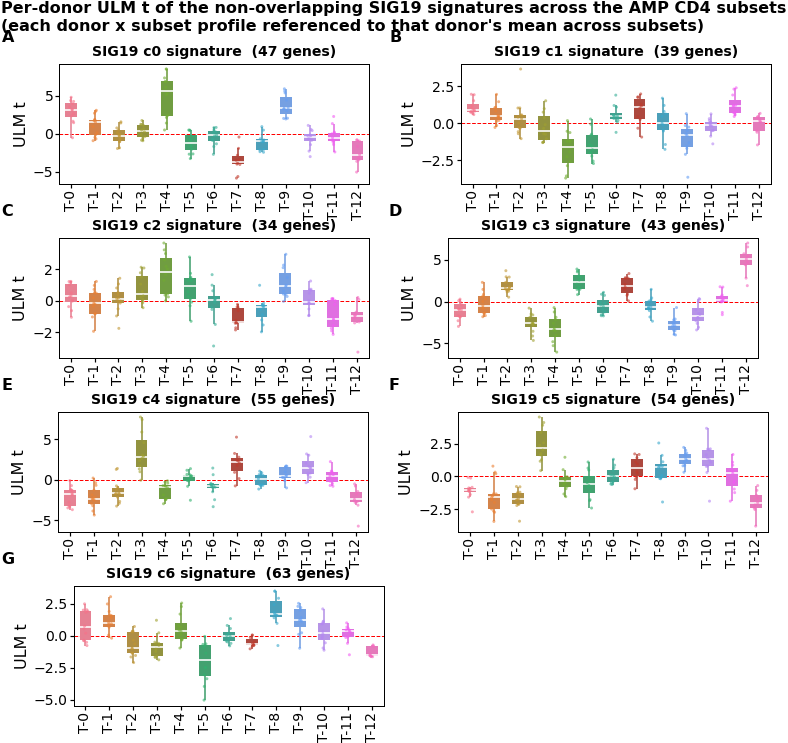

In [9]:
import logging
logging.getLogger("matplotlib.category").setLevel(logging.WARNING)

palette = dict(zip(AMP_ORDER, sns.color_palette("husl", len(AMP_ORDER))))
palette[FOCAL_AMP] = "#c0392b"          # the subset under test, called out in every panel

mp = cns.multipanel(max_width=520,
                    title="Per-donor ULM t of the non-overlapping SIG19 signatures across the AMP "
                          "CD4 subsets\n(each donor x subset profile referenced to that donor's "
                          "mean across subsets)",
                    title_fontweight="bold", loc="left")

for label, ct in zip("ABCDEFG", SIG19_ORDER):
    sub = enrich_rep[enrich_rep["sig19_cluster"] == ct]
    mp.panel(label, 155, 60)
    ax = cns.boxplot(sub, x="cluster", y="estimate", order=AMP_ORDER,
                     hue="cluster", palette=palette, showoutliers=False)
    cns.stripplot(sub, x="cluster", y="estimate", order=AMP_ORDER,
                  hue="cluster", palette=palette, size=1.5, showmedian=False,
                  alpha=0.6, linewidth=0, jitter=True)
    ax.axhline(0, color="red", lw=0.5, zorder=0, linestyle="--")
    ax.set_title(f"SIG19 {ct} signature  ({len(sets[ct])} genes)", fontsize=7)
    ax.set(xlabel="", ylabel="ULM t")
    ax.tick_params(axis="x", labelrotation=90)
    for spine in ax.spines.values():
        spine.set_visible(True)

cns.savefig(f"{OUT_DIR}/sig19_{TAG}_replicates_boxplot_all_sets.pdf")

In [10]:
rows = []
for ct in SIG19_ORDER:
    sub = enrich_rep[enrich_rep["sig19_cluster"] == ct]
    x_focal = sub.loc[sub["cluster"] == FOCAL_AMP, "estimate"]
    for other in AMP_ORDER:
        if other == FOCAL_AMP:
            continue
        x_other = sub.loc[sub["cluster"] == other, "estimate"]
        t_stat, pval = stats.ttest_ind(x_focal, x_other, equal_var=False)
        rows.append(dict(sig19_cluster=ct, group1=FOCAL_AMP, group2=other,
                         n1=x_focal.size, n2=x_other.size,
                         mean1=x_focal.mean(), mean2=x_other.mean(),
                         delta=x_focal.mean() - x_other.mean(),
                         t_stat=t_stat, pval=pval))

focal_tests = pd.DataFrame(rows)
focal_tests["qval"] = multipletests(focal_tests["pval"], method="fdr_bh")[1]
focal_tests["significant_fdr"] = focal_tests["qval"] < 0.05
focal_tests.to_csv(f"{OUT_DIR}/sig19_{TAG}_T7_vs_other_subsets_welch.csv", index=False)

display(focal_tests[focal_tests["sig19_cluster"] == FOCAL_SIG19]
        .sort_values("delta").reset_index(drop=True)
        .round({"mean1": 3, "mean2": 3, "delta": 3, "t_stat": 3, "pval": 4, "qval": 4}))

# where does T-7 rank for each signature, and which subset tops each one?
tbl = pd.concat([rep_mean.loc[FOCAL_AMP].rename(f"mean ULM t in {FOCAL_AMP}"),
                 rep_mean.rank(ascending=False, axis=0).loc[FOCAL_AMP]
                 .rename(f"rank of {FOCAL_AMP} / {len(AMP_ORDER)}"),
                 rep_mean.idxmax(axis=0).rename("highest-scoring subset"),
                 rep_mean.max(axis=0).rename("its mean ULM t")], axis=1)
display(tbl.round(2))

,sig19_cluster,group1,group2,n1,n2,mean1,mean2,delta,t_stat,pval,qval,significant_fdr
0,c3,T-7,T-12,10,9,1.877,4.838,-2.961,-4.589,0.0005,0.0010,True
1,c3,T-7,T-5,10,12,1.877,2.400,-0.523,-1.165,0.2585,0.3016,False
2,c3,T-7,T-2,10,13,1.877,1.858,0.019,0.045,0.9647,0.9647,False
3,c3,T-7,T-11,10,11,1.877,0.232,1.645,3.554,0.0022,0.0040,True
4,c3,T-7,T-1,10,13,1.877,-0.216,2.092,4.269,0.0003,0.0008,True
5,c3,T-7,T-6,10,12,1.877,-0.467,2.344,5.248,0.0000,0.0002,True
6,c3,T-7,T-8,10,11,1.877,-0.552,2.428,5.196,0.0001,0.0002,True
7,c3,T-7,T-0,10,12,1.877,-1.116,2.993,6.654,0.0000,0.0000,True
8,c3,T-7,T-10,10,12,1.877,-1.544,3.421,6.884,0.0000,0.0000,True
9,c3,T-7,T-3,10,12,1.877,-2.617,4.494,9.610,0.0000,0.0000,True


,mean ULM t in T-7,rank of T-7 / 13,highest-scoring subset,its mean ULM t
sig19_cluster,,,,
c0,-3.54,13.0,T-4,5.06
c1,0.83,3.0,T-11,1.20
c2,-1.07,13.0,T-4,1.71
c3,1.88,3.0,T-12,4.84
c4,2.01,2.0,T-3,3.37
c5,0.63,4.0,T-3,2.43
c6,-0.52,9.0,T-8,1.88


### 6.3 T-3, T-4 and T-7 only

Tukey HSD across the three pairs within each signature; `q_global` BH-corrects across 7 x 3. Tukey
ignores that most profiles share donors, so it is conservative.

In [11]:
TRIO = ["T-3", "T-4", "T-7"]
TRIO_PALETTE = dict(zip(TRIO, ["#1B9E77FF", "#D95F02FF", "#7570B3FF"]))
TRIO_PAIRS = [("T-3", "T-4"), ("T-4", "T-7"), ("T-3", "T-7")]   # short brackets drawn first

trio = enrich_rep[enrich_rep["cluster"].isin(TRIO)].copy()
trio["cluster"] = pd.Categorical(trio["cluster"].astype(str), categories=TRIO, ordered=True)

tukey_rows = []
for ct in SIG19_ORDER:
    sub = trio[trio["sig19_cluster"] == ct]
    samples = [sub.loc[sub["cluster"] == g, "estimate"].to_numpy() for g in TRIO]
    res = stats.tukey_hsd(*samples)
    ci = res.confidence_interval()
    for g1, g2 in TRIO_PAIRS:
        i, j = TRIO.index(g1), TRIO.index(g2)
        tukey_rows.append(dict(
            sig19_cluster=ct, group1=g1, group2=g2,
            n1=samples[i].size, n2=samples[j].size,
            mean1=samples[i].mean(), mean2=samples[j].mean(),
            mean_diff=samples[i].mean() - samples[j].mean(),
            ci_low=ci.low[i, j], ci_high=ci.high[i, j],
            statistic=res.statistic[i, j], pvalue=res.pvalue[i, j]))

tukey = pd.DataFrame(tukey_rows)
tukey["q_global"] = multipletests(tukey["pvalue"], method="fdr_bh")[1]
tukey.to_csv(f"{OUT_DIR}/sig19_{TAG}_trio_tukey_hsd.csv", index=False)

print("mean per-donor ULM t")
display(trio.pivot_table(index="cluster", columns="sig19_cluster", values="estimate",
                         observed=True, aggfunc="mean").loc[TRIO, SIG19_ORDER].round(2))
display(tukey.round({"mean1": 2, "mean2": 2, "mean_diff": 2, "ci_low": 2, "ci_high": 2,
                     "statistic": 2, "pvalue": 4, "q_global": 4}))

mean per-donor ULM t


sig19_cluster,c0,c1,c2,c3,c4,c5,c6
cluster,,,,,,,
T-3,0.32,-0.27,0.75,-2.62,3.37,2.43,-0.85
T-4,5.06,-1.79,1.71,-3.23,-1.33,-0.35,0.58
T-7,-3.54,0.83,-1.07,1.88,2.01,0.63,-0.52


,sig19_cluster,group1,group2,n1,n2,mean1,mean2,mean_diff,ci_low,ci_high,statistic,pvalue,q_global
0,c0,T-3,T-4,12,12,0.32,5.06,-4.74,-6.70,-2.79,-4.74,0.0000,0.0000
1,c0,T-4,T-7,12,10,5.06,-3.54,8.60,6.55,10.65,8.60,0.0000,0.0000
2,c0,T-3,T-7,12,10,0.32,-3.54,3.86,1.81,5.90,3.86,0.0002,0.0004
3,c1,T-3,T-4,12,12,-0.27,-1.79,1.52,0.46,2.59,1.52,0.0038,0.0057
4,c1,T-4,T-7,12,10,-1.79,0.83,-2.62,-3.74,-1.51,-2.62,0.0000,0.0000
5,c1,T-3,T-7,12,10,-0.27,0.83,-1.10,-2.22,0.02,-1.10,0.0546,0.0716
6,c2,T-3,T-4,12,12,0.75,1.71,-0.96,-1.94,0.03,-0.96,0.0579,0.0716
7,c2,T-4,T-7,12,10,1.71,-1.07,2.78,1.75,3.81,2.78,0.0000,0.0000
8,c2,T-3,T-7,12,10,0.75,-1.07,1.82,0.79,2.85,1.82,0.0004,0.0008
9,c3,T-3,T-4,12,12,-2.62,-3.23,0.61,-0.70,1.93,0.61,0.4898,0.5143


2026-09-23 09:58:13 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.


2026-09-23 09:58:13 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.
2026-09-23 09:58:13 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.
2026-09-23 09:58:13 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.
2026-09-23 09:58:13 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.
2026-09-23 09:58:13 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.
2026-09-23 09:58:13 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.


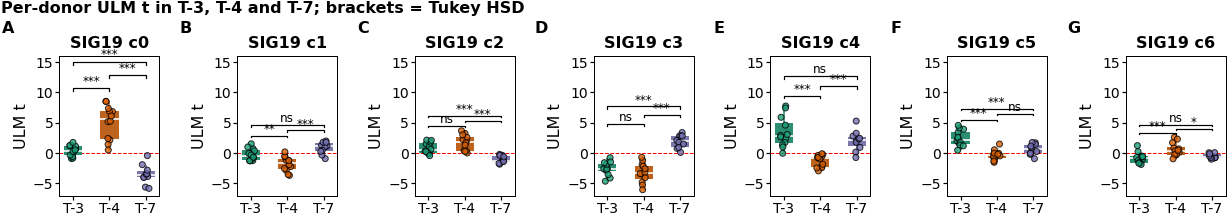

In [12]:
def tukey_brackets(ax, rows, order, y0, span):
    """Stack one significance bracket per pairwise comparison above the data."""
    step = 0.12 * span
    y = y0 + step
    for _, r in rows.iterrows():
        x1, x2 = order.index(r["group1"]), order.index(r["group2"])
        ax.plot([x1, x1, x2, x2], [y, y + step * 0.3, y + step * 0.3, y],
                lw=0.6, color="black", clip_on=False)
        ax.text((x1 + x2) / 2, y + step * 0.35, stars(r["pvalue"]) or "ns",
                ha="center", va="bottom", fontsize=6)
        y += step * 1.25
    return y


mp = cns.multipanel(max_width=800,
                    title="Per-donor ULM t in T-3, T-4 and T-7; brackets = Tukey HSD",
                    title_fontweight="bold", loc="left")

for label, ct in zip("ABCDEFG", SIG19_ORDER):
    sub = trio[trio["sig19_cluster"] == ct]
    rows = tukey[tukey["sig19_cluster"] == ct]
    mp.panel(label, 50, 70)
    # pairs=None: cnsplots would annotate with Mann-Whitney U, and these brackets are Tukey
    ax = cns.boxplot(sub, x="cluster", y="estimate", order=TRIO,
                     hue="cluster", palette=TRIO_PALETTE, showoutliers=False)
    cns.stripplot(sub, x="cluster", y="estimate", order=TRIO,
                  hue="cluster", palette=TRIO_PALETTE, size=3, showmedian=False,
                  alpha=0.8, linewidth=0.5, edgecolor="black", jitter=True)
    ax.axhline(0, color="red", lw=0.5, zorder=0, linestyle="--")

    lo, hi = sub["estimate"].min(), sub["estimate"].max()
    span = hi - lo
    tukey_brackets(ax, rows, TRIO, hi, span)
    ax.set(xlabel="", ylabel="ULM t", ylim=(-7,16))
    ax.set_title(f"SIG19 {ct}", fontsize=8)
    for spine in ax.spines.values():
        spine.set_visible(True)

cns.savefig(f"{OUT_DIR}/sig19_{TAG}_trio_boxplot_tukey.pdf")

### 6.3b Same trio, faceted by subset

The seven signatures compared within each subset (Tukey across 21 pairs, `q_global` across 3 x 21).
Most pairs reach `q_global < 0.05`, so brackets are drawn only for significant pairs involving
`c3`; the full table is in the CSV.

2026-09-23 09:58:17 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.
2026-09-23 09:58:17 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.
2026-09-23 09:58:17 | [INFO] Boxplots represent the median and bottom and upper quartiles; whiskers correspond to the 1.5 times the interquartile range.


38 of 63 pairs at q_global < 0.05


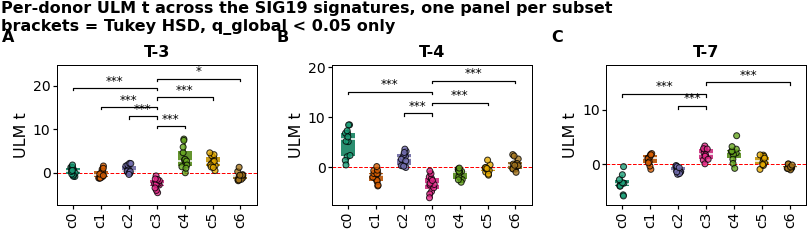

In [13]:
SIG19_PAIRS = list(combinations(SIG19_ORDER, 2))
SIG19_PALETTE = dict(zip(SIG19_ORDER, sns.color_palette("Dark2", len(SIG19_ORDER))))

tukey_sig19_rows = []
for g in TRIO:
    sub = trio[trio["cluster"] == g]
    samples = [sub.loc[sub["sig19_cluster"] == ct, "estimate"].to_numpy() for ct in SIG19_ORDER]
    res = stats.tukey_hsd(*samples)
    ci = res.confidence_interval()
    for ct1, ct2 in SIG19_PAIRS:
        i, j = SIG19_ORDER.index(ct1), SIG19_ORDER.index(ct2)
        tukey_sig19_rows.append(dict(
            cluster=g, group1=ct1, group2=ct2,
            mean1=samples[i].mean(), mean2=samples[j].mean(),
            mean_diff=samples[i].mean() - samples[j].mean(),
            ci_low=ci.low[i, j], ci_high=ci.high[i, j],
            statistic=res.statistic[i, j], pvalue=res.pvalue[i, j]))

tukey_sig19 = pd.DataFrame(tukey_sig19_rows)
tukey_sig19["q_global"] = multipletests(tukey_sig19["pvalue"], method="fdr_bh")[1]
tukey_sig19.to_csv(f"{OUT_DIR}/sig19_{TAG}_trio_by_subset_tukey_hsd.csv", index=False)
print(f"{(tukey_sig19['q_global'] < 0.05).sum()} of {len(tukey_sig19)} pairs at q_global < 0.05")

mp = cns.multipanel(max_width=800,
                    title="Per-donor ULM t across the SIG19 signatures, one panel per subset\n"
                          "brackets = Tukey HSD, q_global < 0.05 only",
                    title_fontweight="bold", loc="left")
lo, hi = trio["estimate"].min(), trio["estimate"].max()
span = hi - lo

for label, g in zip("ABC", TRIO):
    sub = trio[trio["cluster"] == g]
    # only significant pairs involving the focal signature (<= 6 per panel)
    rows = (tukey_sig19[(tukey_sig19["cluster"] == g)
                        & (tukey_sig19["q_global"] < 0.05)
                        & ((tukey_sig19["group1"] == FOCAL_SIG19)
                           | (tukey_sig19["group2"] == FOCAL_SIG19))]
            .assign(_w=lambda d: (d["group1"].map(SIG19_ORDER.index)
                                  - d["group2"].map(SIG19_ORDER.index)).abs())
            .sort_values("_w"))          # short brackets first, so they stack cleanly
    mp.panel(label, 100, 70)
    ax = cns.boxplot(sub, x="sig19_cluster", y="estimate", order=SIG19_ORDER,
                     hue="sig19_cluster", palette=SIG19_PALETTE, showoutliers=False)
    cns.stripplot(sub, x="sig19_cluster", y="estimate", order=SIG19_ORDER,
                  hue="sig19_cluster", palette=SIG19_PALETTE, size=3, showmedian=False,
                  alpha=0.8, linewidth=0.5, edgecolor="black", jitter=True)
    ax.axhline(0, color="red", lw=0.5, zorder=0, linestyle="--")
    top = tukey_brackets(ax, rows, SIG19_ORDER, hi, span)
    ax.set(xlabel="", ylabel="ULM t", ylim=(lo - 0.1 * span, top + 0.1 * span))
    ax.set_title(g, fontsize=8)
    ax.tick_params(axis="x", labelrotation=90)
    for spine in ax.spines.values():
        spine.set_visible(True)

cns.savefig(f"{OUT_DIR}/sig19_{TAG}_trio_boxplot_by_subset.pdf")

## 7. Summary

One row per AMP subset: per-donor ULM mean of the focal `c3` signature and its Welch q against
`T-7`, plus the `c1` signature for context.

In [14]:
c3_mean = (enrich_rep[enrich_rep["sig19_cluster"] == FOCAL_SIG19]
           .groupby("cluster", observed=True)["estimate"]
           .agg(c3_ulm_t="mean", c3_sem="sem", n_donors="size"))
c3_welch = (focal_tests[focal_tests["sig19_cluster"] == FOCAL_SIG19]
            .set_index("group2")["qval"].rename("c3_welch_q_vs_T7"))
c1_col = rep_mean["c1"].rename("c1_ulm_t")

final = (c3_mean.join(c3_welch).join(c1_col)
         .sort_values("c3_ulm_t", ascending=False))
final.index.name = "amp_cluster"
final.to_csv(f"{OUT_DIR}/sig19_{TAG}_summary_by_amp_subset.csv")
display(final.round(3))

print(f"{FOCAL_AMP} ranks {list(final.index).index(FOCAL_AMP) + 1} / {len(final)} "
      f"on {FOCAL_SIG19}.")

,c3_ulm_t,c3_sem,n_donors,c3_welch_q_vs_T7,c1_ulm_t
amp_cluster,,,,,
T-12,4.838,0.548,9,0.001,-0.063
T-5,2.400,0.293,12,0.302,-1.457
T-7,1.877,0.340,10,NaN,0.834
T-2,1.858,0.243,13,0.965,0.349
T-11,0.232,0.314,11,0.004,1.205
T-1,-0.216,0.353,13,0.001,0.616
T-6,-0.467,0.289,12,0.000,0.538
T-8,-0.552,0.320,11,0.000,0.040
T-0,-1.116,0.294,12,0.000,1.088


T-7 ranks 3 / 13 on c3.
